In [ ]:
from fermion import *

n = 8
d = 2*n
ps = np.linspace(0.0, 1.0)
reps = 50

means, stderrs = [], []
for p in ps:
    print(f"Simulating p = {p}...")
    gmns = []
    for r in range(reps):
        rhos = get_mipt_rho_1d_ferm(n, d, p, subsyst=3, all_matrices=True, closed=True, gpu=True)
        this_gmn = [gmn(rho) for rho in rhos]
        gmns.extend(this_gmn)
        print(f"Realisations: {r}/{reps}", end='\r', flush=True)
    means.append(np.mean(gmns))
    stderrs.append(np.std(gmns)/np.sqrt(reps))
    print(f"\GMN: {means[-1]:.8g} ± {stderrs[-1]:.3g}")

In [2]:
from fermion import *
import numpy as np

n = 8
d = 2*n
ps = np.linspace(0.0, 1.0, 21)
reps = 50

means, stderrs = run_fermion_gmn_scan(
    n=n,
    d=d,
    ps=ps,
    reps=reps,
    subsyst=3,
    all_matrices=True,
    closed=True,
    gpu=True,

    # Safe default strategy for GPU:
    # circuit simulation stays serial on the GPU;
    # GMN SDPs run in parallel on CPU.
    gmn_workers=8,
    mosek_threads=1,
)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps, means, yerr=stderrs, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1)
ax1.set_xlabel('Measurement rate $p$')
ax1.set_ylabel(r'GMN')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.75, 0.95, f"n = {n}\nPeriods = {int(d/2)}\nRealisations = {reps}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

Simulating p = 0.0...
Realisations: 50/50
Solving 400 GMN SDPs with 8 workers...

GMN: 0 ± 0
Simulating p = 0.05...
Realisations: 50/50
Solving 400 GMN SDPs with 8 workers...

GMN: 0.00059597668 ± 0.000508
Simulating p = 0.1...
Realisations: 50/50
Solving 400 GMN SDPs with 8 workers...


KeyboardInterrupt: 

In [ ]:
from fermion import *
import numpy as np

from mipt_rho3_bin_writer import Rho3BinWriter, ring_subsystem_qubits

n = 8
d = 2 * n
ps = np.linspace(0.0, 1.0, 21)
realisations = 1000

subsystem_qubits = ring_subsystem_qubits(n, closed=True)

with Rho3BinWriter(
    "rho3_python_fermion.bin",
    total_qubits=n,
    subsystem_qubits=subsystem_qubits,
    periods=d,
    realizations=realisations,
    p_vals=ps,
) as writer:
    for p_index, p in enumerate(ps):
        print(f"Simulating p = {p}...")
        for r in range(realisations):
            rhos = get_mipt_rho_1d(
                n, d, p,
                subsyst=3,
                all_matrices=True,
                closed=True,
            )

            writer.write_record(
                p_index=p_index,
                realization=r,
                p=float(p),
                rhos=rhos,
            )
            print(f"Realisations: {r}/{realisations}", end='\r', flush=True)
        print()

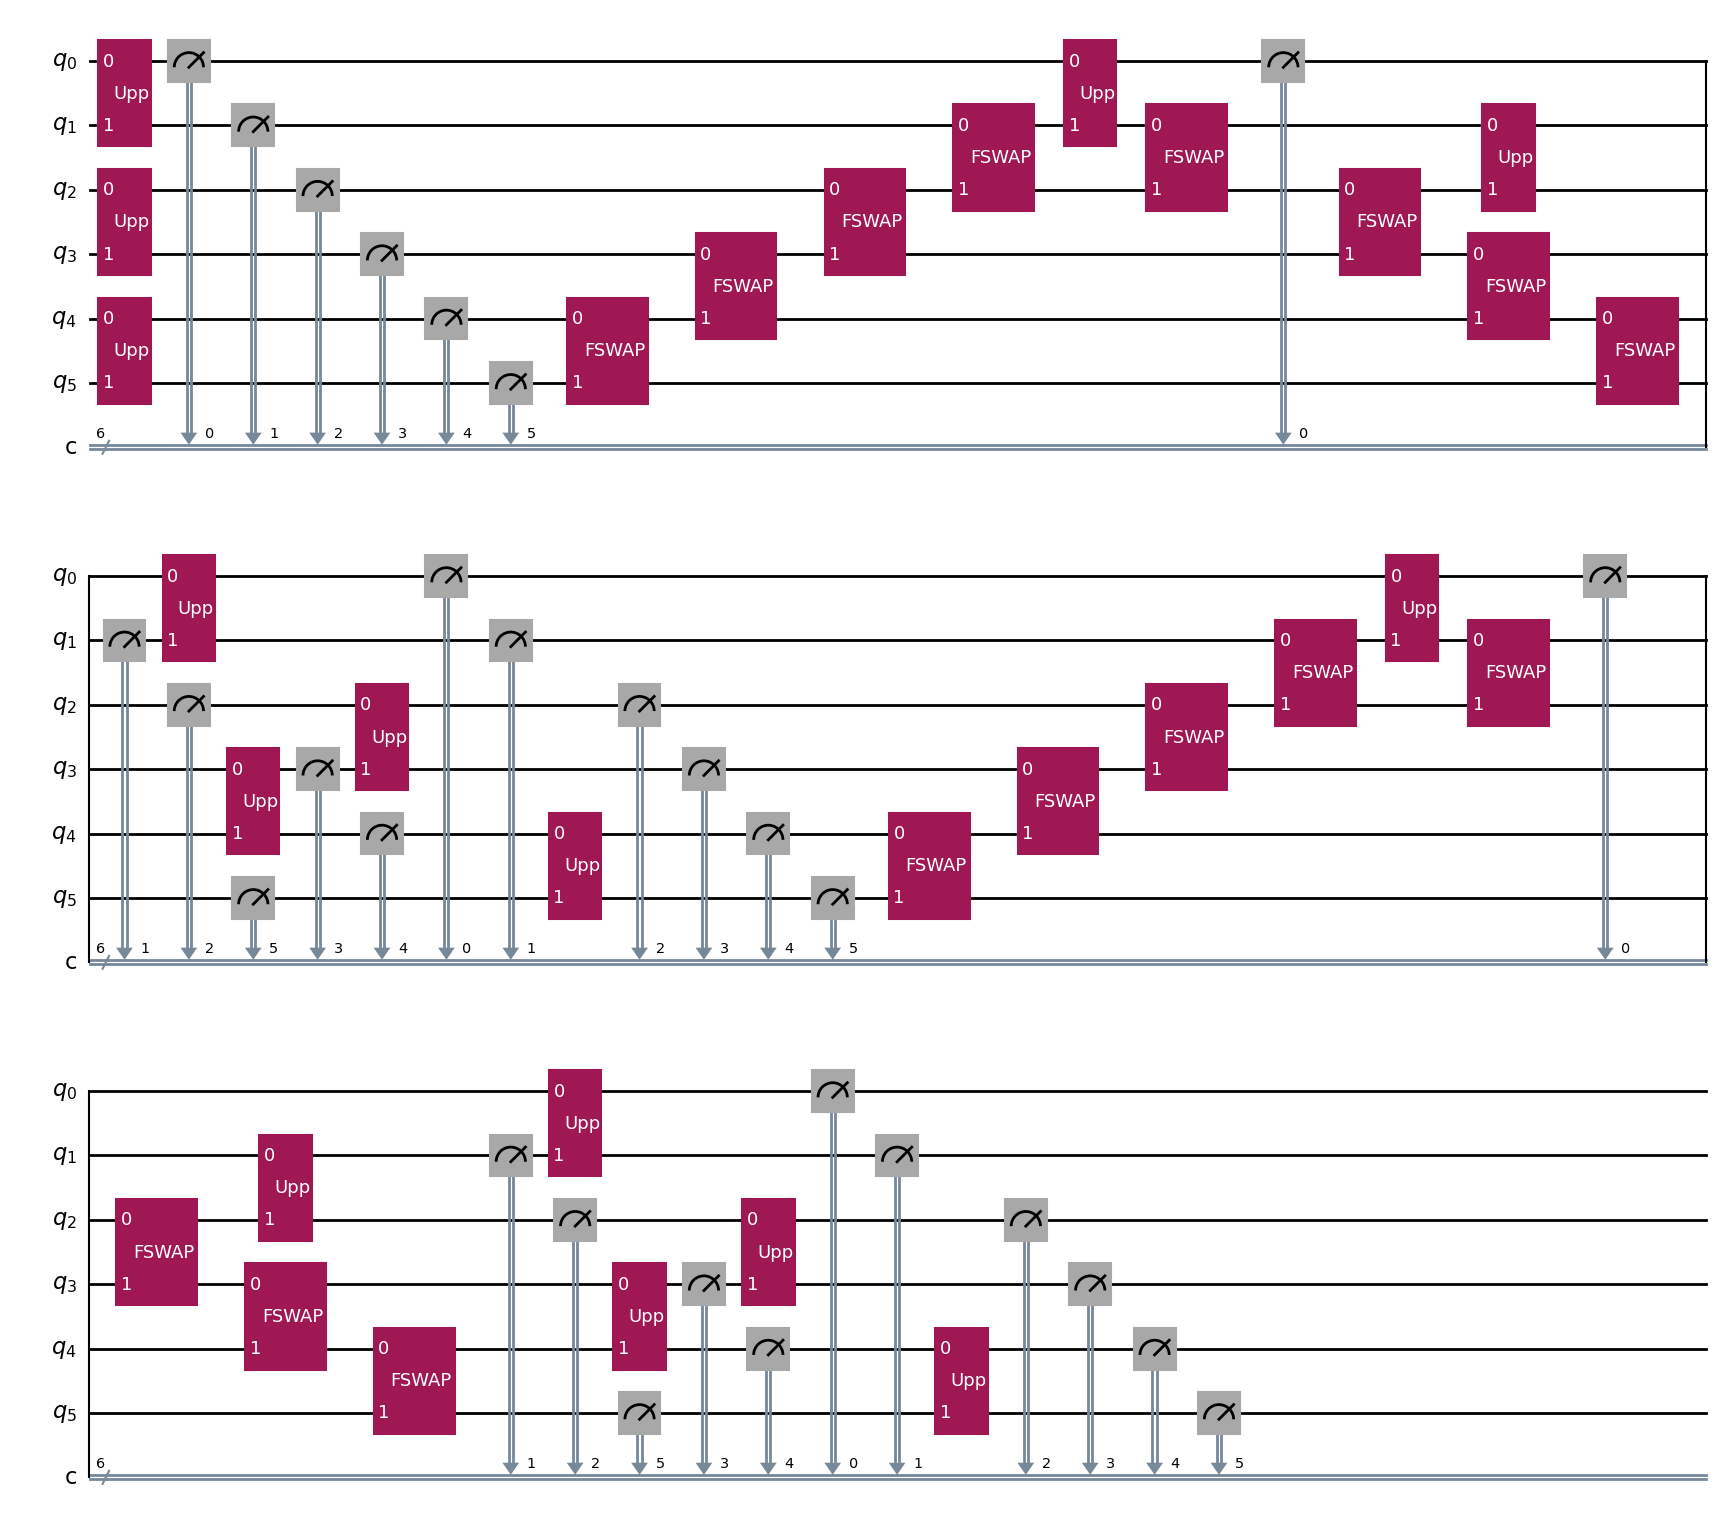

In [2]:
from fermion import random_mipt_1d_ferm
qc = random_mipt_1d_ferm(6, 4, 1.0, closed=True)
qc.draw("mpl")

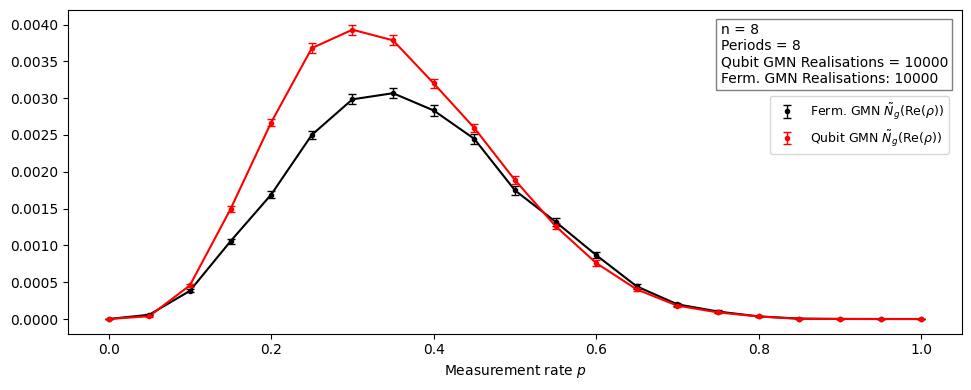

In [7]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# import fermion GMN data
df = pd.read_csv('python_fermion_real_10k.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
gmn_values = data_array[1]

# import qubit GMN data
df2 = pd.read_csv('gmn_data_python_arch_real_10k.csv')
data_array2 = df2.to_numpy().transpose()
qubit_ps = data_array2[0]
qubit_gmn_values = data_array2[1]

n = 8
periods = 8
realizations = 10000
qubit_realizations = 10000
res = 21
p_min = 0.0
p_max = 1.0

# get means +/- stds for fermionic GMN
ps_unique = list(set(ps))
gmn_means = []
gmn_stds = []
for p in ps_unique:
    gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
    gmn_means.append(np.mean(gmn_values_for_p))
    gmn_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))

# get means +/- stds for qubit GMN
qubit_ps_unique = list(set(ps))
qubit_gmn_means = []
qubit_gmn_stds = []
for p in qubit_ps_unique:
    gmn_values_for_p = [gmn for gmn, p_val in zip(qubit_gmn_values, qubit_ps) if p_val == p]
    qubit_gmn_means.append(np.mean(gmn_values_for_p))
    qubit_gmn_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(qubit_realizations*n))


# plot fermionic GMN
sorted_pairs = sorted(zip(ps_unique, gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"Ferm. GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='black')
# ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

# plot qubit GMN
sorted_pairs = sorted(zip(qubit_ps_unique, qubit_gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
ax1.errorbar(qubit_ps_unique, qubit_gmn_means, yerr=qubit_gmn_stds, fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=r"Qubit GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='red')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.73, 0.96, f"n = {n}\nPeriods = {periods}\nQubit GMN Realisations = {qubit_realizations}\nFerm. GMN Realisations: {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

fig.legend(bbox_to_anchor=(0.96, 0.675), loc="center right", fontsize=9)
fig.tight_layout()

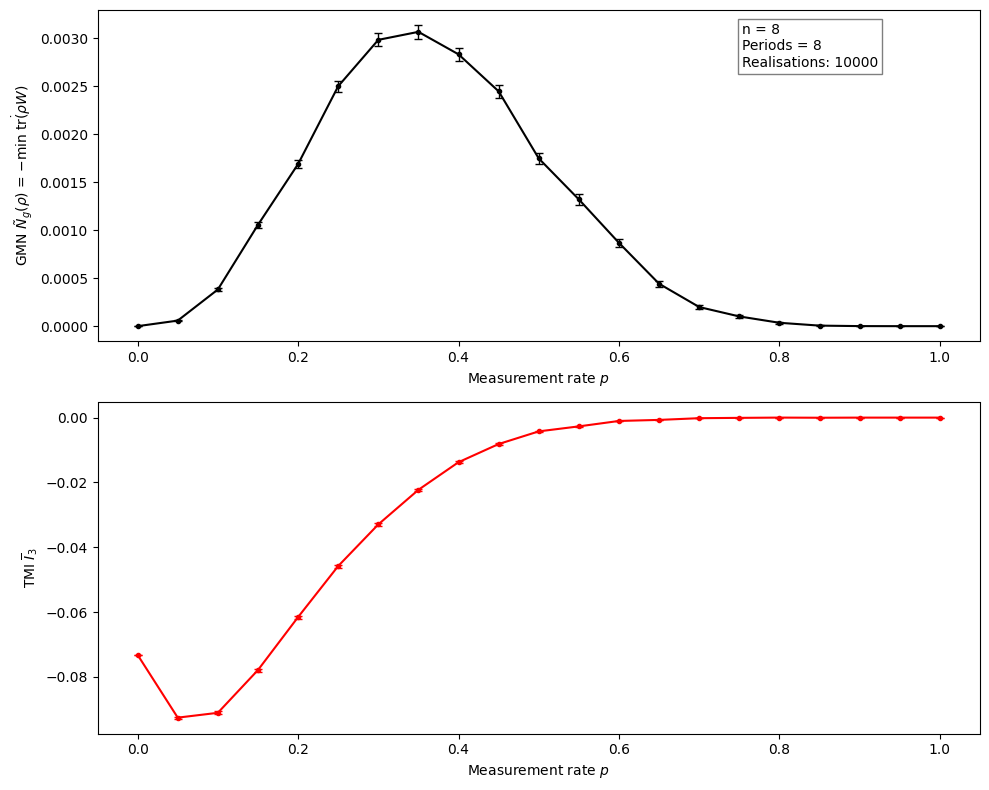

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# import fermion GMN data
df = pd.read_csv('python_fermion_real_10k.csv')
data_array = df.to_numpy().transpose()
ps = data_array[0]
gmn_values = data_array[1]

# import fermion TMI data
df2 = pd.read_csv('python_tmi_fermion.csv')
data_array2 = df2.to_numpy().transpose()
tmi_ps = data_array2[2]
tmi_values = data_array2[8]

n = 8
periods = 8
realizations = 10000
res = 21
p_min = 0.0
p_max = 1.0

# get means +/- stds for fermionic GMN
ps_unique = list(set(ps))
gmn_means = []
gmn_stds = []
for p in ps_unique:
    gmn_values_for_p = [gmn for gmn, p_val in zip(gmn_values, ps) if p_val == p]
    gmn_means.append(np.mean(gmn_values_for_p))
    gmn_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))

# get means +/- stds for qubit GMN
tmi_ps_unique = list(set(ps))
tmi_means = []
tmi_stds = []
for p in tmi_ps_unique:
    gmn_values_for_p = [gmn for gmn, p_val in zip(tmi_values, tmi_ps) if p_val == p]
    tmi_means.append(np.mean(gmn_values_for_p))
    tmi_stds.append(np.std(gmn_values_for_p, ddof=1)/np.sqrt(realizations*n))


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
# plot fermionic GMN
sorted_pairs = sorted(zip(ps_unique, gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\text{Re}(\rho))$")
# ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='black')
ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

# plot qubit GMN
sorted_pairs = sorted(zip(tmi_ps_unique, tmi_means))
x_sorted, y_sorted = zip(*sorted_pairs)
ax2.errorbar(tmi_ps_unique, tmi_means, yerr=tmi_stds, fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=r"TMI $\overline{I}_e$")
ax2.set_xlabel('Measurement rate $p$')
ax2.plot(x_sorted, y_sorted, color='red')
ax2.set_ylabel(r'TMI $\overline{I}_3$')

props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.73, 0.96, f"n = {n}\nPeriods = {periods}\nRealisations: {realizations}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# fig.legend(bbox_to_anchor=(0.96, 0.675), loc="center right", fontsize=9)
fig.tight_layout()